# Learning Representations by Back-Propagating Errors

## Research Paper Implementation

This project implements and explores the learning procedure described in the research paper **“Learning representations by back-propagating errors”** by David E. Rumelhart, Geoffrey E. Hinton, and Ronald J. Williams, published in *Nature* in 1986.

The paper presents a learning procedure called **back-propagation** for networks of neuron-like units. The procedure repeatedly adjusts the weights of connections in a network to reduce the difference between the network's actual output and the desired output. Through this process, hidden units can learn internal representations that capture important features and regularities of the task.

The implementation in this notebook aims to understand and reproduce the core ideas presented in the paper. Rather than relying entirely on high-level deep-learning frameworks, the main back-propagation algorithm will first be implemented from scratch using NumPy.

The project will then use this implementation to explore the types of learning tasks presented in the original paper, including mirror-symmetry detection and family-tree relationships.

## Objectives

The main objectives of this implementation are:

* Understand the motivation behind back-propagation.
* Understand how a multilayer neural network learns internal representations.
* Implement forward propagation from scratch.
* Implement the backward propagation of errors using the chain rule.
* Implement gradient-descent weight updates.
* Experiment with hidden-layer representations.
* Reproduce selected experiments described in the original paper.
* Compare the implementation results with the results reported by the authors.


### Implementing Backpropagation From Scratch

We will first implement the core learning procedure using NumPy. This allows us to explicitly calculate the forward pass, error, gradients, and weight updates instead of hiding these operations behind a deep-learning framework.

#### Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#### Simple trainer


In [10]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

#### Activation Function

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

#### Initialize the network

In [12]:
np.random.seed(42)

input_size = 2
hidden_size = 3
output_size = 1

W1 = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
b1 = np.zeros((1, hidden_size))

W2 = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))
b2 = np.zeros((1, output_size))

#### Forward Propagation

In [13]:
z1 = X @ W1 + b1
a1 = sigmoid(z1)
z2 = a1 @ W2 + b2
a2 = sigmoid(z2)

In [14]:
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

#### Error

In [15]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

_, _, _, predictions = forward(X, W1, b1, W2, b2)

print(predictions)
print("Initial loss:", mse(y, predictions))

[[0.5031718 ]
 [0.49050181]
 [0.5182279 ]
 [0.50564505]]
Initial loss: 0.2501378858531557


#### Back Propagation

In [16]:
delta2 = (a2 - y) * sigmoid_derivative(a2)

dW2 = a1.T @ delta2

db2 = np.sum(delta2, axis=0, keepdims=True)

In [17]:
# Propagate error to the hidden layer
delta1 = (delta2 @ W2.T) * sigmoid_derivative(a1)

dW1 = X.T @ delta1
db1 = np.sum(delta1, axis=0, keepdims=True)

#### Update weights

In [18]:
learning_rate = 0.5

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

#### Combined Training

In [21]:
epochs = 10000
learning_rate = 0.5

loss_history = []

for epoch in range(epochs):

    # Forward pass
    z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)

    # Calculate loss
    loss = mse(y, a2)
    loss_history.append(loss)

    # Backward pass
    delta2 = (a2 - y) * sigmoid_derivative(a2)

    dW2 = a1.T @ delta2
    db2 = np.sum(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ W2.T) * sigmoid_derivative(a1)

    dW1 = X.T @ delta1
    db1 = np.sum(delta1, axis=0, keepdims=True)

    # Update parameters
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.250128
Epoch 1000, Loss: 0.249739
Epoch 2000, Loss: 0.022550
Epoch 3000, Loss: 0.002465
Epoch 4000, Loss: 0.001201
Epoch 5000, Loss: 0.000781
Epoch 6000, Loss: 0.000575
Epoch 7000, Loss: 0.000453
Epoch 8000, Loss: 0.000373
Epoch 9000, Loss: 0.000316


#### Test the network

In [22]:
_, _, _, predictions = forward(X, W1, b1, W2, b2)

print("Predictions:")
print(predictions)

print("\nRounded predictions:")
print(np.round(predictions))

print("\nActual:")
print(y)

Predictions:
[[0.01667654]
 [0.98170398]
 [0.98328805]
 [0.01434148]]

Rounded predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Actual:
[[0.]
 [1.]
 [1.]
 [0.]]


#### Visualize Learning

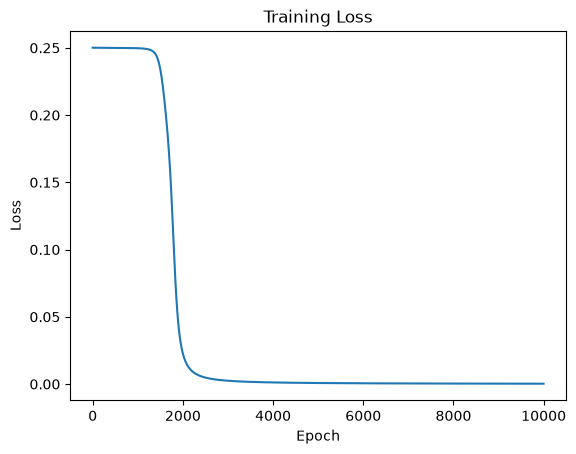

In [23]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()